# How to complete the tutorial

- Read through the text and run code chunks!
- Some code chunks are already filled in for you.
- Others don't have code in them, just write your own code based on instructions.
- If you would like to add text or code blocks, or take notes on your own copy, **make sure you save a copy to your Drive**.
- Some of the things you find here might be on the weekly quiz.

In [ ]:
library(tidyverse)

## **Introduction**
  
In this tutorial, you will learn about how to use R's built in functions for working with distributions. We will specifically work with two discrete distributions—the **binomial distribution** and the **Poisson distribution**—and two continuous distributions—the **Normal distribution** and the **uniform distribution**.

## **Random sampling**
  
One crucial component of performing simulations is randomly sampling data from a known distribution. There is a family of functions in R that can perform this task. Today we will discuss `rnorm()`, `rbinom()`, `rpois()`, and `runif()`.
  
All these functions operate in a similar way. They require the user to specify:
  
1. The **sample size** to be drawn from the distribution.
2. The **parameters** of the distribution from which the sample is to be drawn. Sometimes R has default values for these parameters, and other times the function will not run unless the R user specifies their values.

### **`rnorm()`**
  
Let's demonstrate the use of one of these functions, `rnorm()`. `rnorm()` randomly draws values from the *normal distribution*.
  
`rnorm()` has three arguments: `n`, `mean`, and `sd`. `n` is the **sample size**, while `mean` and `sd` are the distribution parameters to be specified (i.e., $\mu$ & $\sigma$). By default, `rnorm()` assumes a `mean` of 0 and a `sd` of 1.
  

In [ ]:
# randomly draw 10 values from the normal with mean 0 and sd 1
rnorm(n=10)

[1] -2.2079801  0.9149684 -1.5007236  0.6579699 -0.1921564 -0.5892728
 [7] -0.5072045  0.8074722 -0.7359926 -0.9878226

`rnorm()` returns a vector of `n` values randomly drawn from the normal distribution. Above we did not specify the mean or standard deviation, so `rnorm()` used its default values of 0 and 1 (respectively). 0 and 1 are the default values because they are the mean and standard deviation of the **Standard Normal Distribution**.

Notice that this means that you get a sample from a *population* that has mean 0 and standard deviation of 1. Your individual sample does not have to be (and, in fact, it will almost never be) one with mean 0 and standard deviation 1. But it will should not be too far either, especially for larger sample sizes.

Let's check that this is the case. Repeatedly run the code chunk below to see what the mean is for every random sample. (A new random sample is drawn every time you run it.)

In [ ]:
mean(rnorm(100))

[1] 0.02289507

It's never 0, but it's close!

Now, you write the code that would calculate the standard deviation and then run it multiple times. It should be around 1, as long as you don't change the `sd` argument in the `rnorm()` function.

In [ ]:
# Write code here.


You should have noticed that every time the function is run, the sample is different. Sometimes we need exactly reproducible but also "random" results. This can be done by setting a seed. However many times you run the following chunk, `rnorm()` will give you the same result---unless you change what the "seed" is. The seed can be any number you want.

In [ ]:
set.seed(0)
rnorm(10)

[1]  1.262954285 -0.326233361  1.329799263  1.272429321  0.414641434
 [6] -1.539950042 -0.928567035 -0.294720447 -0.005767173  2.404653389

Let's say we want to draw 1000 values from a normal distribution with a mean of 100 and a standard deviation of 15, and plot these values as a histogram. We can easily do so using `rnorm()`.

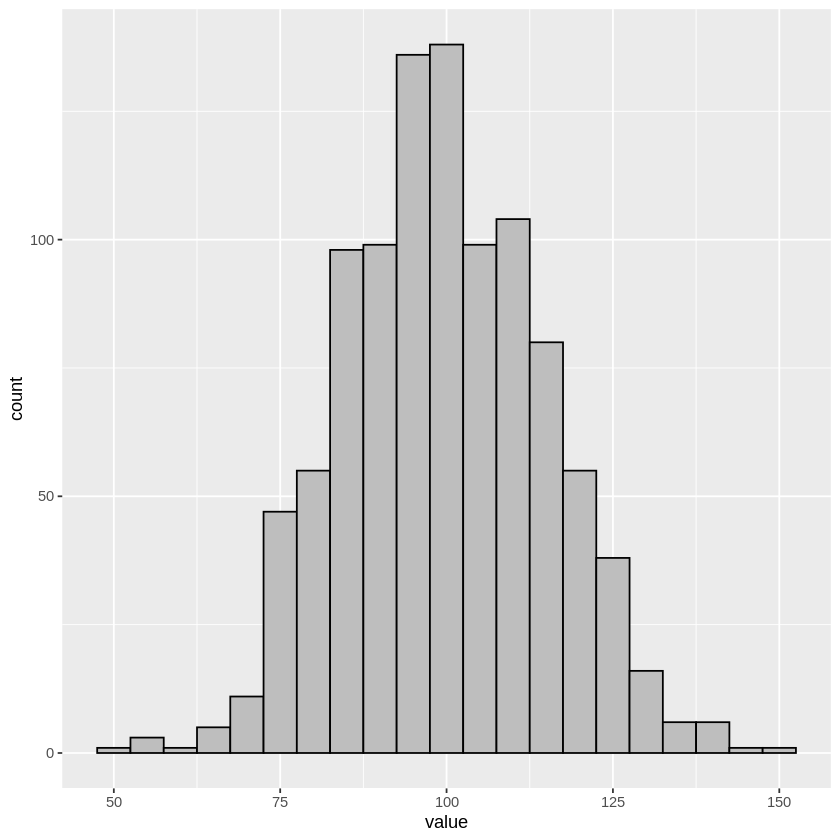

In [ ]:
# randomly drawing values and saving them in a tibble for easy plotting with ggplot
norm_sim <- tibble(
  value=rnorm(n=1000,mean=100,sd=15)
)
# ggplot
ggplot(data=norm_sim,aes(x=value))+
  geom_histogram(binwidth = 5,col='black',fill='gray')

This function is incredibly useful for simulating data, which will become even more important as you learn more about statistics and modeling. Let's learn about the other random simulation functions.

### **`rbinom()`**  
  
`rbinom()` allows simulation from the *binomial distribution*. The binomial distribution is a discrete probability distribution, used to model the probability of *k* successes for a binary event with *n* trials, where the event has a probability of success of *p* on a single trial.
  
For example, a fair coin has a *p* of .5 of landing on heads on a single flip. If heads is defined as a success (1), and tails is defined as a failure (0), we can use `rbinom()` to simulate flipping a coin `n` times. If we tell `rbinom()` that `n=1`, `size=100`, and `prob=.5`, this is equivalent to the following:
  
* Return 1 sample of 100 coin flips (or trials), where there is a .5 probability of heads on a single flip.

In [ ]:
flips <- rbinom(n=1,size=100,prob=.5)
flips

[1] 54

This tells us that when we "flipped" our coin 100 times, we got a sample containing `flips` heads (assuming we define 1 as heads and 0 as tails). More generally speaking, our sample contains `flips` successes out of 100 (meaning there were `100-flips` failures).

Say we want to do our coin flipping sequence (100 times), 5 separate times. We can use `rbinom()` but simply change the `n` argument to 5.

In [ ]:
flips_5 <- rbinom(n=5,size=100,prob=.5)
flips_5

[1] 57 50 53 46 54

Now, we have 5 samples, each containing various numbers of successes out of 100.
  
We don't always have to sample with a .5 probability of success. We can change the `prob` argument to a different value, indicating a different probability of success on a given trial. After all, not every binary event can be assumed to occur with a 50/50 chance.

In the code chunk below, change the probability of success to `0.2` (i.e. 20%), keep the `n` at 5. At each sampling, you should get around 20 successes (100 * 0.2). Are the 5 numbers you get close to 20?

In [ ]:
# Write code here:


This new simulation was done assuming only a .2 probability of success, which is reflected in the random samples. Now the numbers of success center around 20, whereas above they centered around 100.

### **`rpois()`**  
  
Related to the binomial distribution is the *Poisson distribution*. The Poisson distribution is also a discrete probability distribution, used to model the probability of a particular number events occurring in a given time interval.  
  
For example, say that on average, it rains twice a week in Amherst during the summer (this is not accurate!). We can use the Poisson distribution to model the probability that it rains any particular number of times per week, given that the average frequency is 2. This average frequency is known as $\lambda$ (lambda), the Poisson distribution's only parameter. Below is a figure demonstrating the Poisson distribution in this scenario:

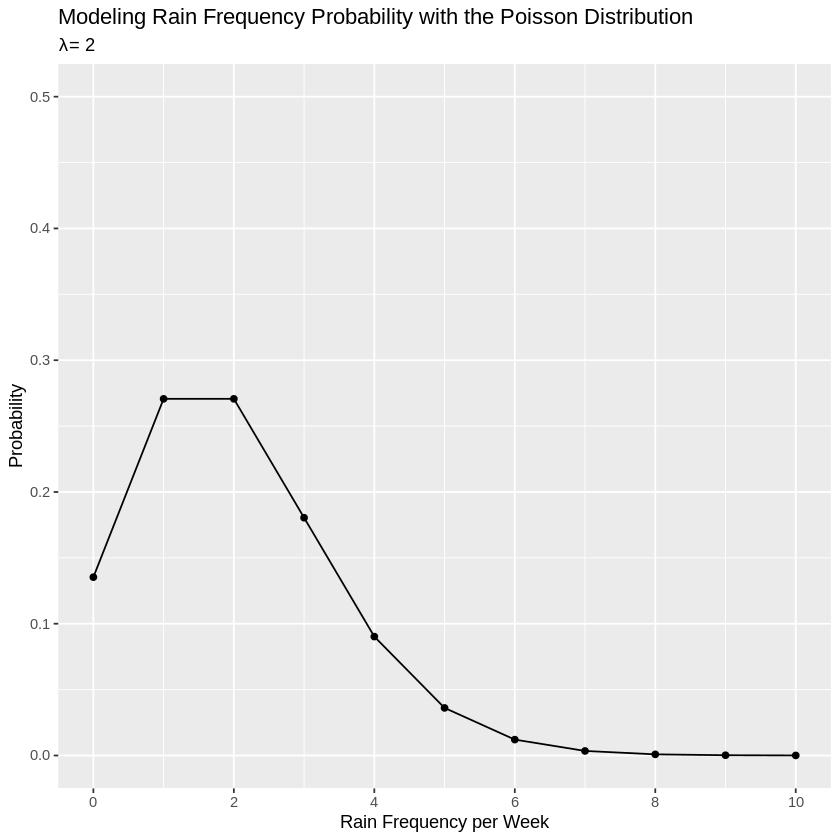

In [ ]:
data <- tibble(
  freqs = 0:10,
  probs = dpois(0:10, 2)
)
ggplot(data, aes(freqs,probs))+
  geom_point()+
  geom_line()+
  scale_x_continuous(breaks = seq(0,10,2))+
  scale_y_continuous(limits = c(0,.5),breaks = seq(0,.5,.1))+
  labs(title="Modeling Rain Frequency Probability with the Poisson Distribution",
       subtitle = expression(paste(lambda,"= 2")),
       x="Rain Frequency per Week",y="Probability")

As you can see, given that the average frequency of rain is twice per week, it's fairly likely that it rains anywhere from 0-4 times per week. However, once you go past 4, the probability of 5, 6, 7, etc...rains per week becomes increasingly tiny.
  
The Poisson distribution is bound by 0 (because we cannot have a negative number of events) and infinity.
  
Now that we know a bit about the Poisson distribution, we can use the `rpois()` function to randomly generate data from it.
  
The `rpois()` function requires two arguments: `n` and `lambda`. `n` refers to the number of random values to generate, and `lambda` is the average number of occurrences per time period.
  
When we run this function, we get random data, with each value corresponding to the number of event occurrences in the time period.

In [ ]:
random_pois <- rpois(n = 10,lambda = 2)
random_pois

[1] 0 1 3 0 1 1 2 5 1 1

As with `rnorm()` and `rbinom()`, `rpois()` returns data in the form of a vector.


  
### **`runif()`**  
  
The *uniform distribution* is a distribution where all values in a given range are equally likely. For example, if we refer a uniform distribution from 0 to 1, this means that all values from 0 to 1 are equally likely. Note that in this case, we are talking about a *continuous uniform distribution*, in which there are infinitely many values between 0 and 1 (or whatever the min and max of our range are). There exists a discrete uniform distribution, but this is beyond the scope of the present discussion.
  
`runif()` requires the argument `n`, the number of values to sample, as well as the distribution parameters `min` and `max`. By default, `runif()` has a `min` of 0 and a `max` of 1.
  
Running `runif(n=10)` returns a vector containing 10 values randomly sampled from a uniform distribution from 0 to 1.

In [ ]:
# randomly sample 10 values from a uniform distribution from 0 to 1
runif(n=10)

[1] 0.11836472 0.78272381 0.06557821 0.78377509 0.12385221 0.77734167
 [7] 0.36134907 0.61593001 0.91704273 0.10522010

If we specify the `min` and `max`, we can change the parameters of the distribution.

In the code chunk below, use `runif()` with `n=10`, but specify the `min` argument to 60 and `max` to 100. All values you get should be be between these values.

In [ ]:
# randomly sample 10 values from a uniform distribution from 60 to 100


### **Summary - Random Sampling Functions**  
  
You've now learned about how to use random sampling functions in R to sample from a normal, binomial, Poisson, and uniform distribution. Here's a quick key to the functions:
  
* `rnorm()` - sample from a normal distribution
    + Arguments:
      + `n` (number of values in the sample)
      + `mean` ($\mu$, mean of the distribution, **default value is 0**)
      + `sd` ($\sigma$, standard deviation of the distribution, **default value is 1**)
* `rbinom()` - sample from a binomial distribution
    + Arguments:
      + `n` (number of samples to draw)
      + `size` (number of trials in each sample, **no default value**)
      + `prob` (probability of success on a given trial, **no default value**)
* `rpois()` - sample from a Poisson distribution    
    + Arguments:
      + `n` (number of values in the sample)
      + `lambda` ($\lambda$, average number of occurences in a given time period, **no default value**)
* `runif()` - sample from a continuous uniform distribution
    + Arguments:
      + `n` (number of values in the sample)
      + `min` (lower limit of the distribution, **default value is 0**)
      + `max` (upper limit of the distribution, **default value is 1**).  

`runif()` is great for randomly generating numbers when programming. `rnorm()` can be useful, but by definition certain values are more likely than others. On the other hand, `runif()` ensures that *all values* are equally likely (within a range).

## **Probability Mass/Probability Density**
  
Yet another family of functions, this time starting with a "d" instead of an "r", can be used to compute probability mass (in the case of a discrete probability distribution) or probability density (in the case of a continuous probability distribution). Let's begin with probability mass.
  
### **Probability Mass**  
  
We can compute probability mass, which essentially tells us, given a distribution, the probability that a random variable is equal to *exactly* a certain value. Let's start out by discussing the binomial distribution.  

#### Binomial distribution - `dbinom()`  
  
Using the function `dbinom()`, we can compute the probability of a specific number of successes (`x`), given the number of trials (`size`) and probability of success on a single trial (`prob`).
  
Let's say we're flipping a fair coin (i.e., 50% chance of heads and 50% chance of tails). We may want to know the probability that we flip the coin 10 times and get *exactly* 4 heads.

In [ ]:
dbinom(x=4,size=5,prob=.5)

[1] 0.15625

There is a `r dbinom(x=4,size=5,prob=.5)` probability that we flip a fair coin 10 times and get *exactly* 4 heads.
  
`dbinom()` is very useful for finding out the probability of a specific outcome in a sequence of binomial trials. Now let's move onto the Poisson distribution and `dpois()`.

Probability mass is very useful. We can use `dbinom()` to plot the probability of all possible outcomes in a series of binomial trials:

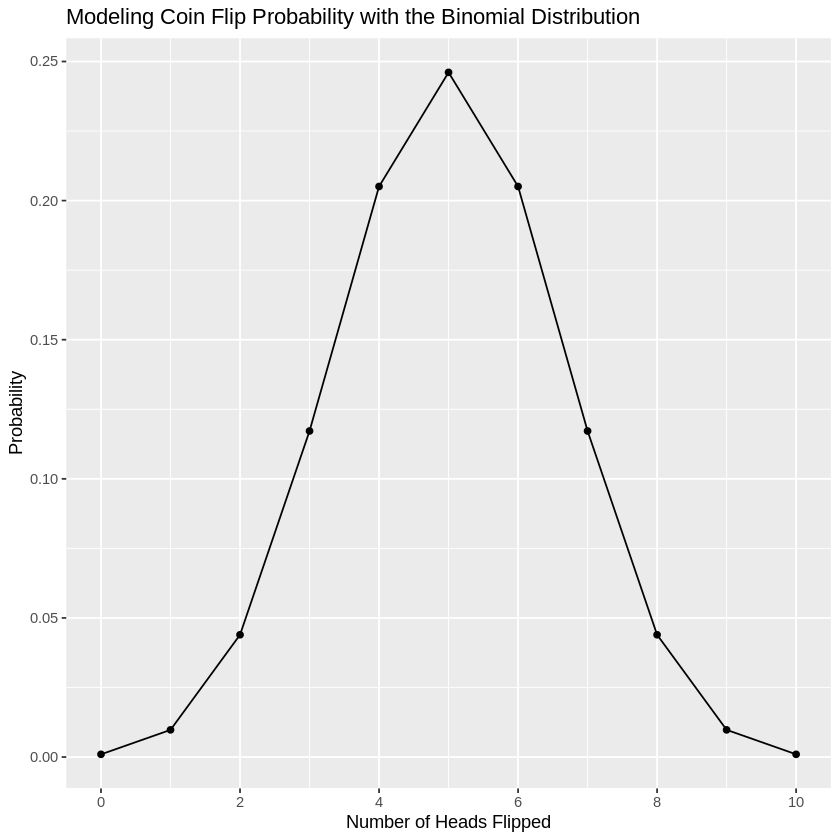

In [ ]:
data_1 <- tibble(
  x = seq(0,10),
  probs = dbinom(x, 10, .5)
)

ggplot(data_1, aes(x,probs))+
  geom_point()+
  geom_line()+
  scale_x_continuous(breaks = seq(0,10,2))+
  labs(x="Number of Heads Flipped",y="Probability",title="Modeling Coin Flip Probability with the Binomial Distribution")

#### Poisson distribution - `dpois()`  
  
Using `dpois()`, we can compute the probability of a specific number of occurrences of an event during an interval, given $\lambda$, the average number of occurrences per interval.
  
Recall our hypothetical example earlier, where we suggested that on average, it rains 2x per week in Amherst. Given this parameter, we can compute the probability that it rains *exactly* 3 times in a week. We will use the `dpois()` function, specifying that `x=3` and `lambda=2`.

In [ ]:
dpois(x=3,lambda=2)

[1] 0.180447

We see that there is a `r dpois(x=3,lambda=2)` probability of it raining 3 times per week in Amherst, given that on average it rains 2x per week.

Like with `dbinom()`, we can use `dpois()` to plot the probability of given outcomes. Though the Poisson distribution is bound only by 0 and infinity, we can plot to a reasonable number of occurrences (at a certain point, values have a probability near 0).

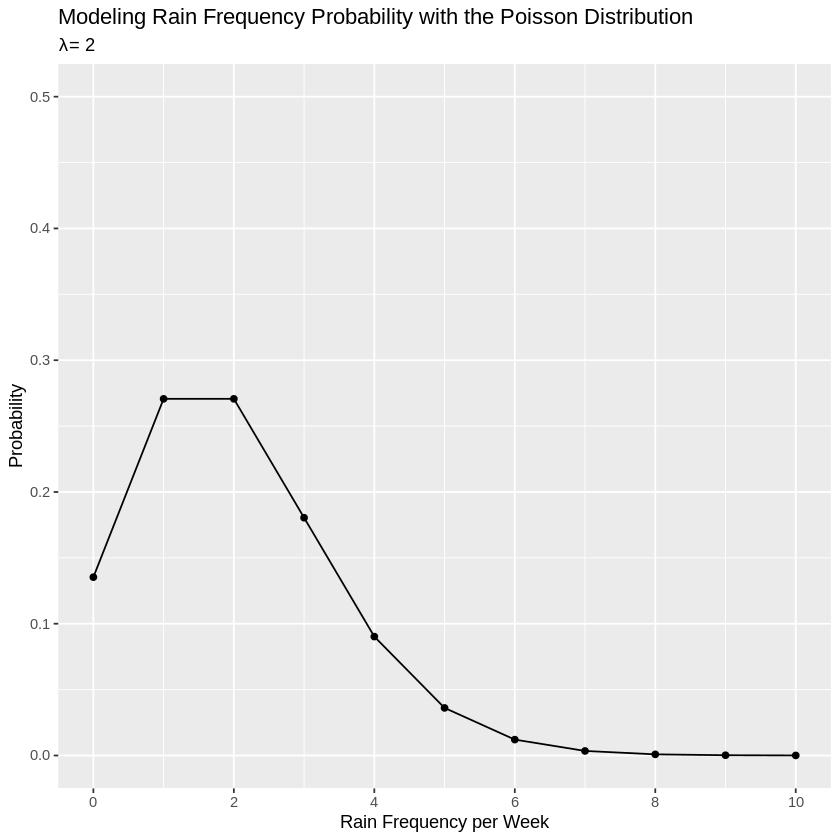

In [ ]:
data_2 <- tibble(
  freqs = 0:10,
  probs = dpois(0:10, 2)
)
ggplot(data_2, aes(freqs,probs))+
  geom_point()+
  geom_line()+
  scale_x_continuous(breaks = seq(0,10,2))+
  scale_y_continuous(limits = c(0,.5),breaks = seq(0,.5,.1))+
  labs(title="Modeling Rain Frequency Probability with the Poisson Distribution",
       subtitle = expression(paste(lambda,"= 2")),
       x="Rain Frequency per Week",y="Probability")

### **Probability Density**
  
When dealing with continuous distributions, the probability of sampling any specific value is so low as to be near 0. For example, given a normal distribution with mean 10 and sd 2, we could sample 10.1, 10.001, 10.001, and so on...The possibilities are literally infinite!
  
So with continuous distributions, we compute something related: probability density. Probability density is still the height of the curve, but it is no longer probability - it is density. However, we can still use it to infer which values are more likely. That is, values with a higher density are still more likely to be sampled. Let's start off by discussing the normal distribution and `dnorm()`.
  
#### Normal distribution - `dnorm()`
  
Using `dnorm()`, we can compute probability density for a particular value `x`, given a normal distribution with a given `mean` and `sd`.
  
Say we have a normal distribution with `mean` 100 and `sd` 15. We can compute the probability density for a particular value `x` as follows:

In [ ]:
dnorm(x=105,mean=100,sd=15)

[1] 0.02515888

As you can see, the probability density for 105 is very small, despite it being close to the mean.   
`dnorm()` can also be used for plotting the normal distribution. While it's computationally impossible to compute the density for all possible values, we can simply compute the density for a sequence of integers within a reasonable range for the distribution, and use `geom_line()` to draw a line between these points.

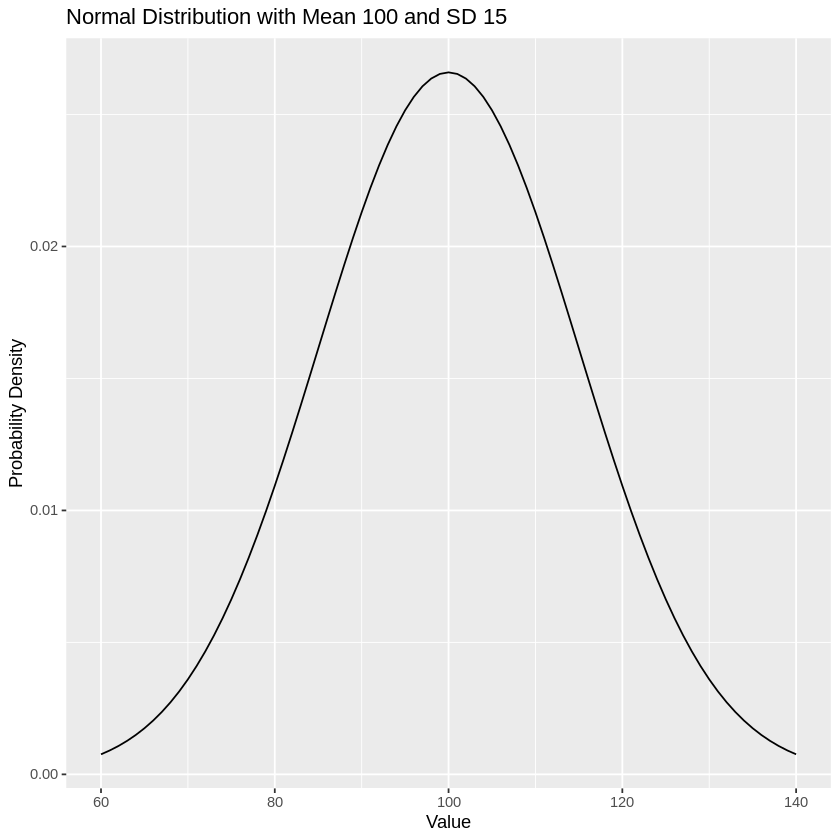

In [ ]:
data_3 <- tibble(
  x=seq(60,140),
  y=dnorm(seq(60,140),mean=100,sd=15)
)
ggplot(data_3, aes(x,y))+
  geom_line()+
  labs(x="Value",y="Probability Density",title="Normal Distribution with Mean 100 and SD 15")

As you can see we end up with a smooth normal distribution.
  
While the probability density for any individual point is low, we can still interpret these values **relative to one another**. By this we mean that points higher on the curve are still more likely than those lower on the curve. For example, it's more likely to a sample a point within 1 SD of the mean than outside 1 SD of the mean. This is reflected in the height of the curve.   

#### Uniform distribution - `dunif()`
  
We can also compute the density for a point on the uniform distribution using `dunif()`. `dunif()` requires the point `x`, as well as the `min` and `max` values of the distribution.

In [ ]:
dunif(x=5,min=1,max=10)

[1] 0.1111111

### **Summary - Probability Mass/Probability Density Functions**  
  
You've now learned about how to use probability density and probability mass functions in R. Here's a quick key to the functions:
  
* `dbinom()` - probability mass of point on binomial distribution
    + Arguments:
      + `x` (number of successes)
      + `size` (number of trials, **no default value**)
      + `prob` (probability of success on a given trial, **no default value**)
* `dpois()` - probability mass of point on Poisson distribution
    + Arguments:
      + `x` (number of occurences)
      + `lambda` ($\lambda$, average number of occurences in a given time period, **no default value**)      
* `dnorm()` - density of point on normal distribution
    + Arguments:
      + `x` (value to get density of)
      + `mean` ($\mu$, mean of the distribution, **default value is 0**)
      + `sd` ($\sigma$, standard deviation of the distribution, **default value is 1**)
* `dunif()` - density of point on continuous uniform distribution
    + Arguments:
      + `x` (value to get density of)
      + `min` (lower limit of the distribution, **default value is 0**)
      + `max` (upper limit of the distribution, **default value is 1**).  

## **Cumulative probability**
  
Cumulative probability allows to get the probability of a *range* of values. In R, these functions begin with a "p" (i.e., `pnorm()`, `pbinom()`, `ppois()`, and `punif()`). Let's start off by discussing `pnorm()`.
  
### **`pnorm()`**
  
Using `pnorm()`, we can get the probability of sampling a value less than or equal to a given value, as well as greater than or equal to a given value.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


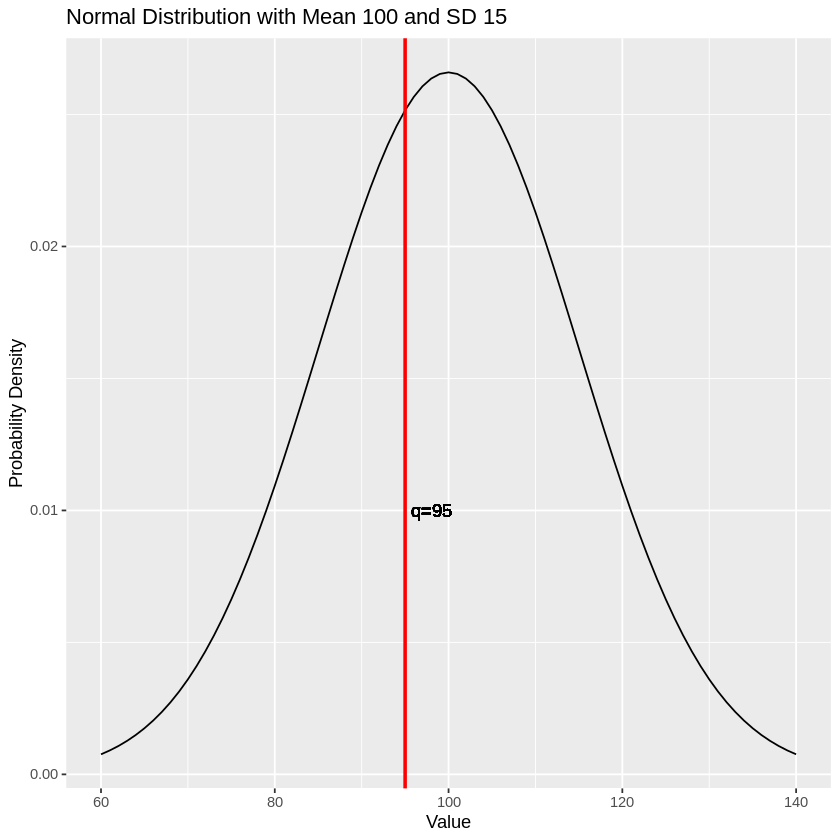

In [ ]:
data_5 <- tibble(
  x=seq(60,140),
  y=dnorm(seq(60,140),mean=100,sd=15)
)
ggplot(data_5, aes(x,y))+
  geom_line()+
  geom_vline(xintercept = 95, col="red",size=1)+
  geom_text(x=98,y=.01,label="q=95")+
  labs(x="Value",y="Probability Density",title="Normal Distribution with Mean 100 and SD 15")

Here, we have a normal distribution with mean 100 and sd 15. We also plotted a red line at 95 on the x axis. Imagine we want to find the probability of sampling a value of 95 or less (anything to the **left** of the red line). We can do so using `pnorm()`, specifying the point with `q`, as well as the `mean` and `sd` of the distribution.

In [ ]:
pnorm(q=95, mean=100, sd=15)

[1] 0.3694413

There is a ~0.37 probability of sampling a value of **95 or less** from a normal distribution with mean 100 and sd 15.
  
What about if we want to find the probability of sampling a value to the **right** of 95? We can simply include the argument `lower.tail=F` (`lower.tail=T` by default, indicating that it always assumes the user is asking for the left side of the curve unless otherwise specified).

There is a ~0.63 probability of sampling a value of **95 or greater** from a normal distribution with mean 100 and sd 15.
  
One final point about `pnorm()`. What do you think happens if you have two `pnorm()` values calculated with the same parameter, but one of them has `lower.tail = ` and you add these two probabilities together? Try it out below:

In [ ]:
# Write code here:

We get a probability of 1! This is because there is a 100% chance of sampling a value *less or equal to 95* **OR** *greater than or equal to 95*. In other words, there is a 100% chance of sampling a value between $-\infty$ and $\infty$.

### **`pbinom()`**
  
We can perform a similar operation on the binomial distribution using `pbinom()`. We simply need to specify the point `q` as well as the number of trials (`size`) and probability of success on a single trial (`prob`).
  
For example, say you want to know the probability of flipping 4 or less heads out of 10 flips, using a fair coin. You can find this probability using `pbinom()`:

In [ ]:
pbinom(q=4,size=10,prob=.5)

[1] 0.3769531

`pbinom()` also has `lower.tail=T` by default. So to find the probability of 4 or greater heads, we can include `lower.tail=F`.

In [ ]:
pbinom(q=4,size=10,prob=.5,lower.tail = F)

[1] 0.6230469

Again, when we add these two probabilities together, we should expect to get a value of 1.

In [ ]:
pbinom(q=4,size=10,prob=.5) + pbinom(q=4,size=10,prob=.5,lower.tail = F)

[1] 1

What happens if we look at the chance of flipping a coing 10 times and getting a probability of 10 or fewer heads? Run `pbinom()` below, but your `q` and `size` should be both 10:

In [ ]:
# Write code here:

We get 1! This makes sense because there's a 100% chance of flipping a coin 10 times and getting 10 or fewer heads. In other words, this **exhausts** all possibilities.

### **`ppois()`**
  
We can use `ppois()` to calculate cumulative probability for a Poisson distribution.
  
Again going back to our rain example, say we want to know the probability of it raining 1 or fewer times in a week, given that on average it rains 2x per week. We can simply run `ppois()` with `q=1` and `lambda=2`.  

In [ ]:
ppois(q=1,lambda=2)

[1] 0.4060058

Just as with `dnorm()` and `dbinom()`, to find the probability of 1 or more occurrences, we simply set `lower.tail=F`.

In [ ]:
ppois(q=1,lambda=2,lower.tail=F)

[1] 0.5939942

Again, these two probabilities sum to 1. Try out below:

In [ ]:
# Write code here:

It's also important to note than when setting `lower.tail=F` with `ppois()`, we calculate the probability from `q` to $\infty$, as the Poisson distribution is bound by 0 on the left and $\infty$ on the right.

### **`punif()`**
  
Lastly, we can use `punif()` to calculate cumulative probability with the uniform distribution.

In [ ]:
punif(q=10,min=0,max=30)

[1] 0.3333333

Above, we calculate the cumulative probability from 10 to the lower limit (0). We could change `q` to 15, which would be mid-point between 0 and 30. What do you think you would get? Try out below:

In [ ]:
# Write code here:

We can also calculate the cumulative probability from 10 to the upper limit (30).

In [ ]:
punif(q=10,min=0,max=30,lower.tail=F)

[1] 0.6666667

And again, these two probabilities will sum to 1.

In [ ]:
punif(q=10,min=0,max=30)+punif(q=10,min=0,max=30,lower.tail=F)

[1] 1

### **Summary - Cumulative Probability Functions**  
  
You've now learned about how to use probability density and probability mass functions in R. Here's a quick key to the functions:
  
* `pnorm()` - cumulative probability of normal distribution
    + Arguments:
      + `q` (point to get cumulative probability of)
      + `mean` ($\mu$, mean of the distribution, **default value is 0**)
      + `sd` ($\sigma$, standard deviation of the distribution, **default value is 1**)  
* `pbinom()` - cumulative probability of binomial distribution
    + Arguments:
      + `q` (point to get cumulative probability of)
      + `size` (number of trials, **no default value**)
      + `prob` (probability of success on a given trial, **no default value**)
* `ppois()` - cumulative probability of point on Poisson distribution
    + Arguments:
      + `q` (point to get cumulative probability of)
      + `lambda` ($\lambda$, average number of occurrences in a given time period, **no default value**)      
* `punif()` - cumulative probability of point on continuous uniform distribution
    + Arguments:
      + `q` (point to get cumulative probability of)
      + `min` (lower limit of the distribution, **default value is 0**)
      + `max` (upper limit of the distribution, **default value is 1**).  

## **Quantile functions**
  
The last family of functions to discuss is the quantile functions. These functions begin with a "q", and we use them when we want to find the specific value on a distribution associated with a particular cumulative probability.
  
### **`qnorm()`**
  
Say we want to find the point on the standard normal distribution where 5% of the distribution is to the left (for example, finding the cutoff value for a z-test). You can do so easily using `qnorm()`, simply specifying `p=.05`.

In [ ]:
qnorm(p=.05)

[1] -1.644854

You can also specify the `mean` and `sd` of the distribution.

In [ ]:
qnorm(p=.05,mean=100,sd=15)

[1] 75.3272

We see that 5% of the normal distribution (with mean 100 and sd 15) is to the left of ~75.33.


In a normal distribution, mean is equal to the median. In other words, half of all observations are to the right and half to the left of the mean. If you set the `p` to 0.5, but mean stays at `100`, what result will you get? Try it below:

In [ ]:
# Write code here:


  We can also change the side of the distribution we look at by changing the argument `lower.tail` to `FALSE`.

In [ ]:
qnorm(p=.05,mean=100,sd=15,lower.tail=FALSE)

[1] 124.6728

This gives us the point where 5% of the distribution is to the **RIGHT**.

### **`qbinom()`**
  
`qbinom()` works similarly. We simply input a cumulative probability value with the `p` argument and specify the parameters to the distribution (`size` and `prob`).

In [ ]:
qbinom(p=.05,size=10,prob=.5)

[1] 2

**This** tells us that 5% of the binomial distribution (with 10 trials and probability of .5 on a single trial) is to the left of 2.

### **`qpois()`**
  
Again, with `qpois()`, we input a cumulative probability value and in return get a point on the distribution. We also specify the Poisson distribution parameter `lambda`.

In [ ]:
qpois(p=.5,lambda=2)

[1] 2

This tells us that 50% of the Poisson distribution (with `lambda` equal to 2) is to the left of 2.
  
### **`qunif()`**
  
With `qunif()`, we input a cumulative probability value and in return get a point on the distribution. We also specify the `min` and `max` of the distribution.

In [ ]:
qunif(p=.05, min=10,max=40)

[1] 11.5

### **Summary - Quantile Functions**  
  
You've now learned about how to use probability density and probability mass functions in R. Here's a quick key to the functions:
  
* `qnorm()` - quantile on normal distribution
    + Arguments:
      + `p` (cumulative probability to get quantile for)
      + `mean` ($\mu$, mean of the distribution, **default value is 0**)
      + `sd` ($\sigma$, standard deviation of the distribution, **default value is 1**)  
* `qbinom()` - quantile on binomial distribution
    + Arguments:
      + `p` (cumulative probability to get quantile for)
      + `size` (number of trials, **no default value**)
      + `prob` (probability of success on a given trial, **no default value**)
* `qpois()` - quantile on Poisson distribution
    + Arguments:
      + `p` (cumulative probability to get quantile for)
      + `lambda` ($\lambda$, average number of occurrences in a given time period, **no default value**)      
* `qunif()` - quantile on continuous uniform distribution
    + Arguments:
      + `p` (cumulative probability to get quantile for)
      + `min` (lower limit of the distribution, **default value is 0**)
      + `max` (upper limit of the distribution, **default value is 1**).

## **Conclusion**
  
In this tutorial, you learned about the distribution functions associated with the normal, uniform, binomial, and Poisson distributions.   